## Exercício prático — Dia 02
Complete os passos no notebook usando a base `base_rh.xlsx` e crie os gráficos finais pedindo ao gerente de produção.

1. Carregue `base_rh.xlsx` com `pd.read_excel(URL)` e converta `Data_Admissao` para datetime. Crie `Ano_Admissao` com `.dt.year`.
2. Use `groupby(["Departamento", "Cargo"])` para contar funcionários e exiba o resultado.
3. Use `groupby("Ano_Admissao")` para contar admissões por ano e filtre 2020–2024 com `query()`.
4. Crie uma tabela de metas de headcount por departamento com `pd.DataFrame` e faça `merge left` com o total por departamento. Identifique se a meta foi atingida.
5. Crie um `pivot_table` de `Salario` médio por `Departamento` e `Genero`. Calcule a diferença `F - M`.
6. Plote admissões por ano com `plt.plot(..., marker="o")`.
7. Plote o `pivot_table` de salário médio por gênero com `pivot.plot(kind="bar")`.
8. Faça commit com mensagem `semana 05 - dia 02: groupby, merge, pivot_table, graficos`.

## Gabarito resumido
- Para filtrar anos: `query("Ano_Admissao >= 2020 and Ano_Admissao <= 2024")`.
- Para calcular diferença salarial por gênero: crie `pivot_genero` e depois `pivot_genero["Diferenca_F_M"] = (pivot_genero["F"] - pivot_genero["M"]).round(2)`.
- Use `bbox_to_anchor=(1, 1)` se a legenda cobrir o gráfico.

## Observações finais
Hoje você aprendeu: `groupby` com múltiplas funções, `reset_index()` após groupby, `unstack()` para barras agrupadas, `merge` para cruzar tabelas e `pivot_table` para relatório cruzado.

1. Carregue `base_rh.xlsx` com `pd.read_excel(URL)` e converta `Data_Admissao` para datetime. Crie `Ano_Admissao` com `.dt.year`.

In [101]:
# Bibliotecas que irei usar
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Aonde está o arquivo que irei trabalhar
URL = (
    "https://raw.githubusercontent.com/"
    "cfneves/turma-visualizacao-de-dados/"
    "master/aulas/semana_04/bases/base_rh.xlsx"
)

# Lendo o arquivo
df = pd.read_excel(URL)

# Transformando a coluna "Data_Admissao" em datetime
df['Data_Admissao'] = pd.to_datetime(
    df['Data_Admissao'],
    format='%d/%m/%Y',
    errors='coerce'
)

# Criando uma nova aba Ano_Admissao.
df['Ano_Admissao'] = df['Data_Admissao'].dt.year

# Imprimindo o dataset e os tipo de cada coluna
print(f'Dataset: {df.shape[0]} linhas x {df.shape[1]} colunas')
print(df.dtypes)

Dataset: 1000 linhas x 11 colunas
ID_Funcionario             int64
Nome                         str
Departamento                 str
Cargo                        str
Salario                  float64
Data_Admissao     datetime64[us]
Genero                       str
Idade                      int64
Estado_Civil                 str
Status                       str
Ano_Admissao               int32
dtype: object


2. Use `groupby(["Departamento", "Cargo"])` para contar funcionários e exiba o resultado.

In [102]:
# Quantidade de funcionários por Departamento/Cargo
qtd_funcionarios = (
    df.groupby(['Departamento', 'Cargo'])['ID_Funcionario'].count().reset_index().rename(columns={'ID_Funcionario': 'Quantidade'})
)

# Imprimindo a quantidade de funcionários por departamento/cargo
print(qtd_funcionarios.to_string(index=False))

Departamento       Cargo  Quantidade
  Financeiro    Analista          40
  Financeiro  Assistente          30
  Financeiro Coordenador          37
  Financeiro     Gerente          44
  Financeiro     Técnico          38
   Logística    Analista          29
   Logística  Assistente          38
   Logística Coordenador          38
   Logística     Gerente          33
   Logística     Técnico          18
    Produção    Analista          22
    Produção  Assistente          41
    Produção Coordenador          40
    Produção     Gerente          43
    Produção     Técnico          36
          RH    Analista          32
          RH  Assistente          35
          RH Coordenador          44
          RH     Gerente          30
          RH     Técnico          25
          TI    Analista          31
          TI  Assistente          25
          TI Coordenador          28
          TI     Gerente          31
          TI     Técnico          32
      Vendas    Analista          24
 

3. Use `groupby("Ano_Admissao")` para contar admissões por ano e filtre 2020–2024 com `query()`.

In [103]:
# Quantidade de admissões por ano
admissoes_ano = (
    df.groupby('Ano_Admissao')['ID_Funcionario']
    .count()
    .reset_index()
    .query('Ano_Admissao >= 2020 and Ano_Admissao <= 2024')
    .rename(columns={'ID_Funcionario': 'Admissoes'})
    .sort_values('Admissoes', ascending=False)
)

# Imprimindo a quantidade de admissões
print(admissoes_ano.to_string(index=False))

 Ano_Admissao  Admissoes
         2024        113
         2022        108
         2023        106
         2020         94
         2021         94


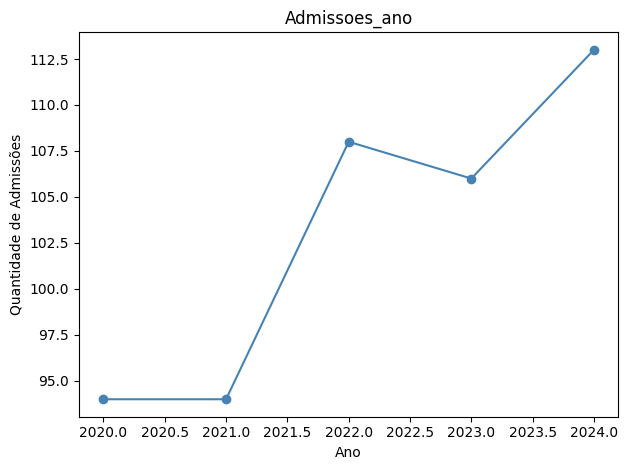

In [104]:
# Plotando as admissões por ano.
admissoes_ordenado = admissoes_ano.sort_values('Ano_Admissao')

plt.plot(
    admissoes_ordenado['Ano_Admissao'],
    admissoes_ordenado['Admissoes'],
    marker='o',
    color='steelblue'
)

plt.title('Admissoes_ano')
plt.xlabel('Ano')
plt.ylabel('Quantidade de Admissões')
plt.tight_layout()
plt.show()

4. Crie uma tabela de metas de headcount por departamento com `pd.DataFrame` e faça `merge left` com o total por departamento. Identifique se a meta foi atingida.

In [105]:
# Quantidade de funcionários atual.
headcount = (
    df.groupby('Departamento')['ID_Funcionario']
    .count()
    .reset_index()
    .rename(columns={'ID_Funcionario': 'HeadCount'})
)

# imprimindo a quantidade de funcionários por departamento
print(headcount.to_string(index=False))

Departamento  HeadCount
  Financeiro        189
   Logística        156
    Produção        182
          RH        166
          TI        147
      Vendas        160


In [106]:
# Criando as metas de headcount por departamento
metas = pd.DataFrame({
    'Departamento': [
        'Produção', 'RH', 'Financeiro',
        'Logística', 'TI', 'Vendas'
    ],
    'Metas_Headcount': [180, 170, 190, 150, 135, 155]
})

# Imprimindo as metas de Funcionários.
print('Tabelas de Metas:')
print(metas.to_string(index=False))

Tabelas de Metas:
Departamento  Metas_Headcount
    Produção              180
          RH              170
  Financeiro              190
   Logística              150
          TI              135
      Vendas              155


In [107]:
# Comparando a tabela metas com a tabela o total

comparacao = pd.merge(
    metas,
    headcount,
    on='Departamento',
    how='left'
)

# Colunas qu indentifica se a meta foi atingida
comparacao['Meta_Atingida'] = comparacao['HeadCount'] >= comparacao['Metas_Headcount']

# Imprimindo a comparação e exibindo se a meta foi ou não atingida 
print('Comparativo de Metas de HeadCount:')
print(comparacao.to_string(index=False))

Comparativo de Metas de HeadCount:
Departamento  Metas_Headcount  HeadCount  Meta_Atingida
    Produção              180        182           True
          RH              170        166          False
  Financeiro              190        189          False
   Logística              150        156           True
          TI              135        147           True
      Vendas              155        160           True


5. Crie um `pivot_table` de `Salario` médio por `Departamento` e `Genero`. Calcule a diferença `F - M`.

In [108]:
# Criando que cruza Salário, Departamento e Genero
# Descobrindo o salario médio por departamento do sexo masculino e feminino
pivot = pd.pivot_table(
    df,
    values='Salario',
    index='Departamento',
    columns='Genero',
    aggfunc='mean',
    fill_value=0
).round(0)

# Imprimindo a tabel pivo que mostra o salário médio por departamento e genero
print(pivot.to_string())

Genero             F       M
Departamento                
Financeiro    8467.0  8209.0
Logística     8843.0  8944.0
Produção      8798.0  9119.0
RH            9009.0  8546.0
TI            8107.0  8177.0
Vendas        8927.0  7752.0


In [109]:
# Qual é a diferença do entre os seus salários
pivot['Diferenca_F_M'] = pivot['F'] - pivot['M']

# Imprimindo a diferença de salários entre F e M
print('Tabela dinâmica de salário médio por departamento e genero')
print(pivot.to_string())

Tabela dinâmica de salário médio por departamento e genero
Genero             F       M  Diferenca_F_M
Departamento                               
Financeiro    8467.0  8209.0          258.0
Logística     8843.0  8944.0         -101.0
Produção      8798.0  9119.0         -321.0
RH            9009.0  8546.0          463.0
TI            8107.0  8177.0          -70.0
Vendas        8927.0  7752.0         1175.0


6. Plote admissões por ano com `plt.plot(..., marker="o")`.

7. Plote o `pivot_table` de salário médio por gênero com `pivot.plot(kind="bar")`.

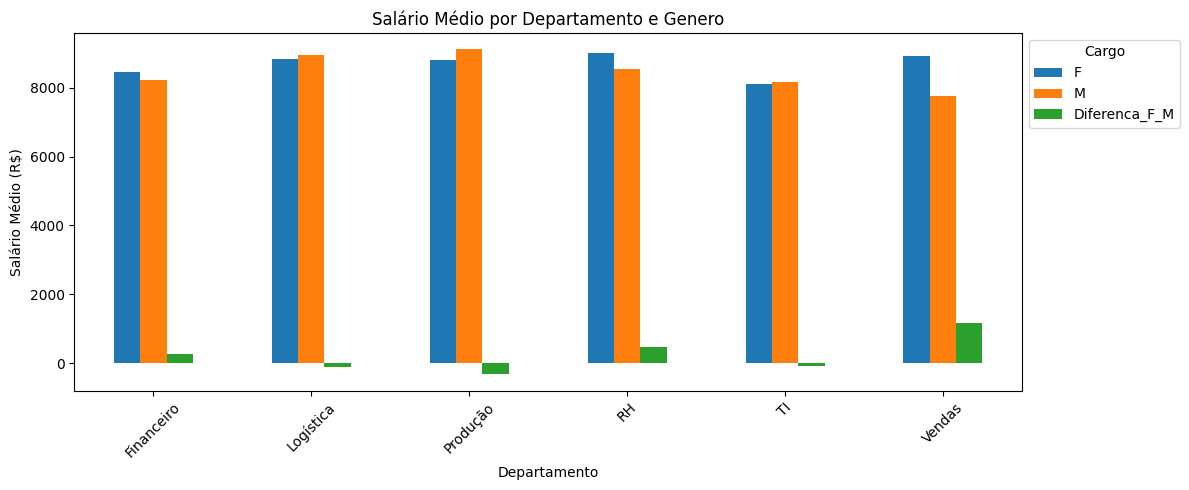

In [110]:
# Plota o resultado do pivot_table em barras agrupadas
pivot.plot(kind="bar", figsize=(12, 5))
plt.title("Salário Médio por Departamento e Genero")
plt.xlabel("Departamento")
plt.ylabel("Salário Médio (R$)")
plt.xticks(rotation=45)
plt.legend(title="Cargo", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()
